In [2]:
import pandas as pd
import numpy as np

features = pd.read_csv("../outputs/feature_table.csv")

print("Dataset shape:", features.shape)
features.head()

Dataset shape: (95, 7)


,Skill,Freq,Trend_Slope,Recency_Weight,Upcoming_Flag,Is_Taught_MSRIT,Taught_Elsewhere_Count
0,advanced sql,8,-4.000000,0.812500,1,1,2
1,api gateway,1,0.000000,0.250000,0,0,0
2,api rate limiting,1,0.000000,1.000000,0,0,0
3,auto scaling,1,0.000000,0.500000,0,0,0
4,aws,29,-1.571429,0.318966,0,1,4


In [3]:
features["Demand_Score"] = (
    features["Freq"] * 0.4 +
    features["Trend_Slope"] * 0.3 +
    features["Recency_Weight"] * 0.3
)

threshold = features["Demand_Score"].quantile(0.65)
print(f"Demand_Score threshold (65th percentile): {threshold:.3f}")

features["Label_MSRIT"] = (
    (features["Demand_Score"] > threshold) &
    (features["Is_Taught_MSRIT"] == 0)
).astype(int)

print("\nClass distribution (before balancing):")
print(features["Label_MSRIT"].value_counts())
print(f"Imbalance ratio: {features['Label_MSRIT'].value_counts()[0] / features['Label_MSRIT'].value_counts()[1]:.1f}:1")

Demand_Score threshold (65th percentile): 2.840

Class distribution (before balancing):
Label_MSRIT
0    74
1    21
Name: count, dtype: int64
Imbalance ratio: 3.5:1


In [4]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = ["Freq", "Trend_Slope", "Recency_Weight", "Upcoming_Flag", "Taught_Elsewhere_Count"]

X = features[FEATURE_COLS]
y = features["Label_MSRIT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("Train class dist:", y_train.value_counts().to_dict())
print("Test class dist:", y_test.value_counts().to_dict())

Train size: 71 | Test size: 24
Train class dist: {0: 55, 1: 16}
Test class dist: {0: 19, 1: 5}


In [5]:
try:
    from imblearn.over_sampling import SMOTE
    
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    
    print("After SMOTE:")
    print("Train size:", X_train_bal.shape[0])
    print("Class distribution:", pd.Series(y_train_bal).value_counts().to_dict())
    smote_available = True

except ImportError:
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")
    print("Falling back to class_weight='balanced' only.")
    X_train_bal, y_train_bal = X_train, y_train
    smote_available = False

After SMOTE:
Train size: 110
Class distribution: {0: 55, 1: 55}


In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_bal, y_train_bal)
print("Model trained successfully.")

Model trained successfully.


In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score

probs_test = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.20, 0.70, 0.05)
results = []
for t in thresholds:
    preds = (probs_test > t).astype(int)
    results.append({
        "Threshold": round(t, 2),
        "F1_gap": round(f1_score(y_test, preds, zero_division=0), 3),
        "Precision_gap": round(precision_score(y_test, preds, zero_division=0), 3),
        "Recall_gap": round(recall_score(y_test, preds, zero_division=0), 3),
    })

threshold_df = pd.DataFrame(results)
best_row = threshold_df.loc[threshold_df["F1_gap"].idxmax()]
best_threshold = best_row["Threshold"]

print(threshold_df.to_string(index=False))
print(f"\n✅ Best threshold by F1: {best_threshold}")

 Threshold  F1_gap  Precision_gap  Recall_gap
      0.20   0.727          0.667         0.8
      0.25   0.800          0.800         0.8
      0.30   0.800          0.800         0.8
      0.35   0.800          0.800         0.8
      0.40   0.800          0.800         0.8
      0.45   0.800          0.800         0.8
      0.50   0.667          0.750         0.6
      0.55   0.667          0.750         0.6
      0.60   0.667          0.750         0.6
      0.65   0.667          0.750         0.6

✅ Best threshold by F1: 0.25


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = (probs_test > best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not a Gap", "Gap Skill"]))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
    index=["Actual: Not Gap", "Actual: Gap"],
    columns=["Predicted: Not Gap", "Predicted: Gap"]
)
print(cm_df)

roc_auc = roc_auc_score(y_test, probs_test)
print(f"\nROC-AUC Score: {roc_auc:.3f}")
print("(ROC-AUC > 0.75 is good for imbalanced binary classification)")

Classification Report:
              precision    recall  f1-score   support

   Not a Gap       0.95      0.95      0.95        19
   Gap Skill       0.80      0.80      0.80         5

    accuracy                           0.92        24
   macro avg       0.87      0.87      0.87        24
weighted avg       0.92      0.92      0.92        24

Confusion Matrix:
                 Predicted: Not Gap  Predicted: Gap
Actual: Not Gap                  18               1
Actual: Gap                       1               4

ROC-AUC Score: 0.958
(ROC-AUC > 0.75 is good for imbalanced binary classification)


In [9]:
importance = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.to_string(index=False))
print("\nNote: Recency_Weight should now be less correlated with Freq after normalisation fix.")

               Feature  Importance
                  Freq    0.551378
           Trend_Slope    0.225296
Taught_Elsewhere_Count    0.110989
        Recency_Weight    0.093085
         Upcoming_Flag    0.019251

Note: Recency_Weight should now be less correlated with Freq after normalisation fix.


In [10]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = cross_val_predict(
    RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=2,
        random_state=42, class_weight="balanced"
    ),
    X, y,
    cv=cv,
    method="predict_proba"
)[:, 1]

features["Recommendation_Prob_MSRIT"] = oof_probs
print("Out-of-fold probabilities computed. No data leakage in final ranking.")

Out-of-fold probabilities computed. No data leakage in final ranking.


In [11]:
gap_skills = features[features["Is_Taught_MSRIT"] == 0].copy()

ranked_msrit = gap_skills.sort_values(
    "Recommendation_Prob_MSRIT", ascending=False
).reset_index(drop=True)

ranked_msrit.to_csv("../outputs/ranked_skills_msrit.csv", index=False)

display_cols = ["Skill", "Freq", "Trend_Slope", "Recency_Weight",
                "Upcoming_Flag", "Taught_Elsewhere_Count",
                "Demand_Score", "Label_MSRIT", "Recommendation_Prob_MSRIT"]

print("Top 15 Recommended Skills for MSRIT Curriculum:")
print(ranked_msrit[display_cols].head(15).to_string(index=False))

Top 15 Recommended Skills for MSRIT Curriculum:
        Skill  Freq  Trend_Slope  Recency_Weight  Upcoming_Flag  Taught_Elsewhere_Count  Demand_Score  Label_MSRIT  Recommendation_Prob_MSRIT
generative ai    15    -9.000000        0.800000              1                       0      3.540000            1                   0.919662
     power bi    14    -2.000000        0.357143              0                       0      5.107143            1                   0.884902
        ci/cd    10    -0.769231        0.250000              0                       0      3.844231            1                   0.876156
       docker    14     0.000000        0.250000              0                       0      5.675000            1                   0.835186
   tensorflow    22     8.000000        0.420455              0                       0     11.326136            1                   0.833898
       golang    22    -2.500000        0.693182              0                       0      8.25795

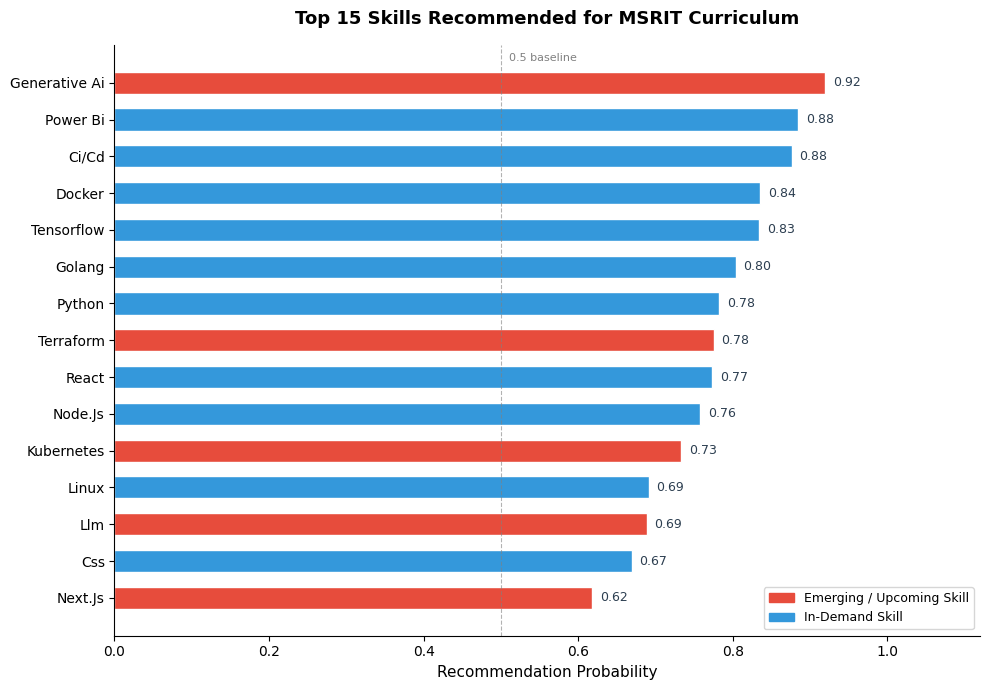

Chart saved to outputs/recommended_skills_chart.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

top15 = ranked_msrit.head(15).copy()

colors = ["#e74c3c" if flag == 1 else "#3498db" for flag in top15["Upcoming_Flag"]]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top15["Skill"].str.title(),
    top15["Recommendation_Prob_MSRIT"],
    color=colors,
    edgecolor="white",
    height=0.6
)

ax.invert_yaxis()

for bar, val in zip(bars, top15["Recommendation_Prob_MSRIT"]):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center", ha="left", fontsize=9, color="#2c3e50"
    )

ax.set_xlabel("Recommendation Probability", fontsize=11)
ax.set_title(
    "Top 15 Skills Recommended for MSRIT Curriculum",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(0, 1.12)
ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(0.51, -0.6, "0.5 baseline", fontsize=8, color="gray")

emerging_patch = mpatches.Patch(color="#e74c3c", label="Emerging / Upcoming Skill")
regular_patch  = mpatches.Patch(color="#3498db", label="In-Demand Skill")
ax.legend(handles=[emerging_patch, regular_patch], loc="lower right", fontsize=9)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/recommended_skills_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to outputs/recommended_skills_chart.png")